# Librerías y lectura de datos

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, silhouette_samples
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
from matplotlib import cm

In [7]:
# Leer el archivo CSV
df = pd.read_csv('historico_siniestros_bogota_d.c_-.csv')

# Mostrar las primeras filas del dataframe
df.head()

,X,Y,OBJECTID,FORMULARIO,CODIGO_ACCIDENTE,FECHA_OCURRENCIA_ACC,ANO_OCURRENCIA_ACC,DIRECCION,GRAVEDAD,CLASE_ACC,LOCALIDAD,FECHA_HORA_ACC,LATITUD,LONGITUD,CIV,PK_CALZADA
0,-74.090924,4.693807,1,A000640275,4484660,2017/06/12 00:00:00+00,2017,AV AVENIDA BOYACA-CL 79 02,SOLO DANOS,CHOQUE,ENGATIVA,2017/06/12 05:30:00+00,4.693807,-74.090924,10006772.0,221236.0
1,-74.121000,4.603000,2,A001233353,10533499,2020/11/19 00:00:00+00,2020,CL 26 S- KR 50 02,CON HERIDOS,OTRO,PUENTE ARANDA,2020/11/19 02:05:00+00,4.603000,-74.121000,16004560.0,NaN
2,-74.042000,4.682000,4,A001232786,10533629,2020/11/10 00:00:00+00,2020,KR 9 - CL 100 02,SOLO DANOS,CHOQUE,USAQUEN,2020/11/10 13:30:00+00,4.682000,-74.042000,30001107.0,NaN
3,-74.166937,4.587187,7,A000200705,4412699,2015/05/11 00:00:00+00,2015,CL 63A-KR 72 S 02,SOLO DANOS,CHOQUE,CIUDAD BOLIVAR,2015/05/11 10:50:00+00,4.587187,-74.166937,19001483.0,136166.0
4,-74.092901,4.607648,8,A000402862,4447845,2016/06/08 00:00:00+00,2016,KR 27-CL 9 14,SOLO DANOS,CHOQUE,LOS MARTIRES,2016/06/08 21:30:00+00,4.607648,-74.092901,14000548.0,239719.0


# Análisis Exploratorio

In [8]:
df.dtypes  # Muestra los tipos de datos de cada columna

,0
X,float64
Y,float64
OBJECTID,int64
FORMULARIO,object
CODIGO_ACCIDENTE,int64
FECHA_OCURRENCIA_ACC,object
ANO_OCURRENCIA_ACC,int64
DIRECCION,object
GRAVEDAD,object
CLASE_ACC,object


In [9]:
df.describe()  # Muestra estadísticas como media, desviación estándar, valores mínimos y máximos

,X,Y,OBJECTID,CODIGO_ACCIDENTE,ANO_OCURRENCIA_ACC,LATITUD,LONGITUD,CIV,PK_CALZADA
count,199146.000000,199146.000000,199146.000000,1.991460e+05,199146.000000,199146.000000,199146.000000,1.974450e+05,1.611720e+05
mean,-74.104096,4.649135,246116.268160,7.368238e+06,2017.760106,4.649135,-74.104096,1.379895e+07,7.588678e+06
std,0.040099,0.057567,128297.631741,3.017820e+06,1.855071,0.057567,0.040099,1.346756e+07,1.840877e+07
min,-74.228300,4.085800,1.000000,4.401420e+06,2015.000000,4.085800,-74.228300,0.000000e+00,0.000000e+00
25%,-74.134196,4.608163,135603.750000,4.458053e+06,2016.000000,4.608163,-74.134196,7.004943e+06,4.326700e+04
50%,-74.103043,4.645415,283027.500000,4.512848e+06,2018.000000,4.645415,-74.103043,1.000758e+07,1.769000e+05
75%,-74.073008,4.690015,358176.750000,1.049794e+07,2019.000000,4.690015,-74.073007,1.500116e+07,2.354850e+05
max,-74.011000,4.828041,421911.000000,1.054926e+07,2021.000000,4.828041,-74.011000,5.000962e+07,9.103049e+07


In [10]:
df.isnull().sum()  # Muestra cuántos valores nulos hay en cada columna

,0
X,0
Y,0
OBJECTID,0
FORMULARIO,0
CODIGO_ACCIDENTE,0
FECHA_OCURRENCIA_ACC,0
ANO_OCURRENCIA_ACC,0
DIRECCION,0
GRAVEDAD,0
CLASE_ACC,0


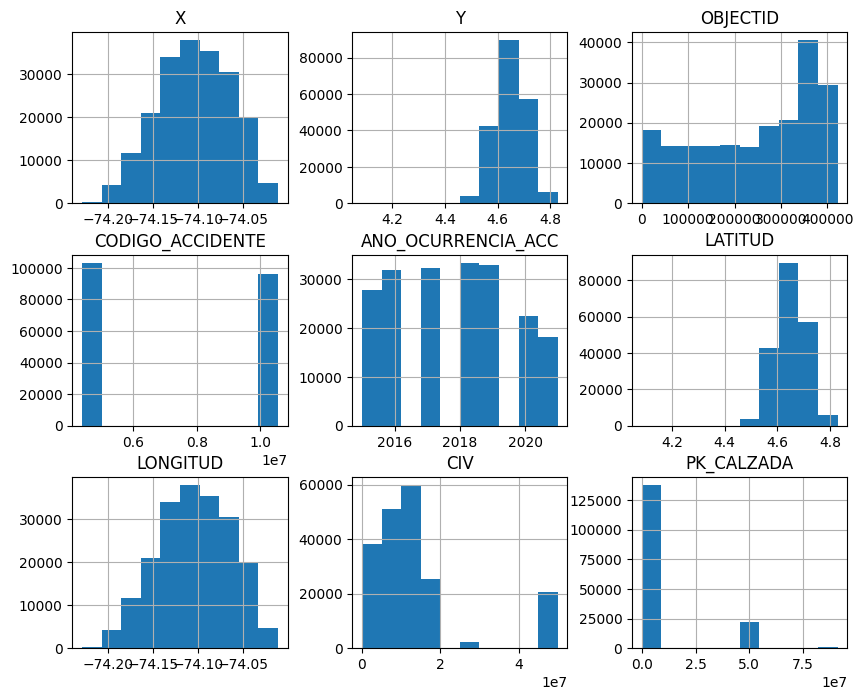

In [11]:
# Histograma para todas las variables numéricas
df.hist(bins=10, figsize=(10, 8))
plt.show()

# Preprocesamiento de datos

In [12]:
# Filtrar los accidentes con muertes
df_muertes = df[df['GRAVEDAD'] == 'CON MUERTOS']
df_muertes.shape

(3239, 16)

In [13]:
# Selección de columnas numéricas relevantes
df_seleccionado = df_muertes[['LATITUD', 'LONGITUD', 'CLASE_ACC', 'LOCALIDAD']]

# Mostrar las primeras filas del nuevo DataFrame
df_seleccionado.head()

,LATITUD,LONGITUD,CLASE_ACC,LOCALIDAD
5,4.778000,-74.042000,ATROPELLO,SUBA
11,4.508000,-74.113000,ATROPELLO,USME
13,4.660000,-74.077000,ATROPELLO,BARRIOS UNIDOS
14,4.526321,-74.140893,VOLCAMIENTO,CIUDAD BOLIVAR
20,4.616000,-74.158000,CHOQUE,KENNEDY


In [15]:
# Codificar la variable 'LOCALIDAD' y 'CLASE_ACC'
df_seleccionado = pd.get_dummies(df_seleccionado, columns=['LOCALIDAD', 'CLASE_ACC'])
df_seleccionado.head()

,LATITUD,LONGITUD,LOCALIDAD_ANTONIO NARINO,LOCALIDAD_BARRIOS UNIDOS,LOCALIDAD_BOSA,LOCALIDAD_CANDELARIA,LOCALIDAD_CHAPINERO,LOCALIDAD_CIUDAD BOLIVAR,LOCALIDAD_ENGATIVA,LOCALIDAD_FONTIBON,...,LOCALIDAD_SUMAPAZ,LOCALIDAD_TEUSAQUILLO,LOCALIDAD_TUNJUELITO,LOCALIDAD_USAQUEN,LOCALIDAD_USME,CLASE_ACC_ATROPELLO,CLASE_ACC_CAIDA DE OCUPANTE,CLASE_ACC_CHOQUE,CLASE_ACC_OTRO,CLASE_ACC_VOLCAMIENTO
5,4.778000,-74.042000,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
11,4.508000,-74.113000,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,False,False,False,False
13,4.660000,-74.077000,False,True,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
14,4.526321,-74.140893,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
20,4.616000,-74.158000,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


# Preparación de datos

In [16]:
# Escalar las variables numéricas
scaler = StandardScaler()
df_normalizado = scaler.fit_transform(df_seleccionado)

In [ ]:
df_normalizado

array([[ 2.35144941,  1.8921832 , -0.16217001, ..., -0.90591709,
        -0.0465386 , -0.30277895],
       [-1.98069474,  0.04733662, -0.16217001, ..., -0.90591709,
        -0.0465386 , -0.30277895],
       [ 0.45814197,  0.98275179, -0.16217001, ..., -0.90591709,
        -0.0465386 , -0.30277895],
       ...,
       [-1.30680565,  0.2292229 , -0.16217001, ..., -0.90591709,
        -0.0465386 , -0.30277895],
       [ 1.64757209,  0.32471684, -0.16217001, ..., -0.90591709,
        -0.0465386 , -0.30277895],
       [-0.10343227, -1.25185112, -0.16217001, ..., -0.90591709,
        -0.0465386 ,  3.3027395 ]])

# Agrupamiento con K-means

In [ ]:
# Método del codo para encontrar el número óptimo de clusters
distorsiones = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_normalizado)
    distorsiones.append(kmeans.inertia_)

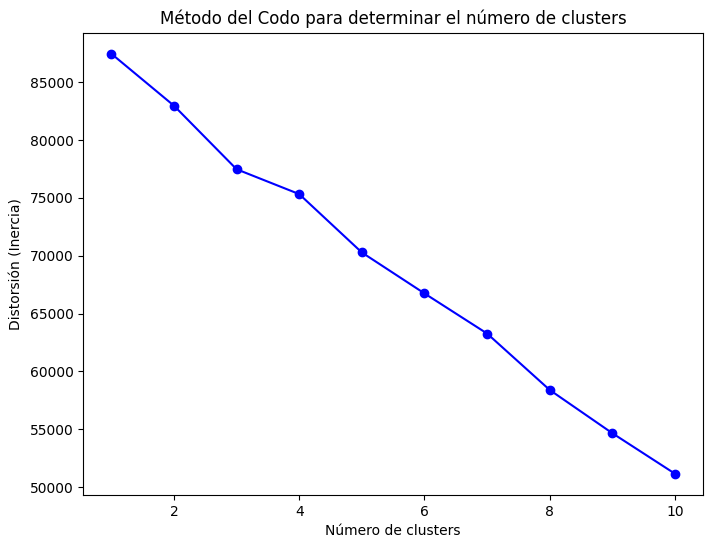

In [ ]:
# Graficar el método del codo
plt.figure(figsize=(8, 6))
plt.plot(K, distorsiones, 'bo-')
plt.xlabel('Número de clusters')
plt.ylabel('Distorsión (Inercia)')
plt.title('Método del Codo para determinar el número de clusters')
plt.show()

In [ ]:
# Aplicar K-means con k = 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
df_seleccionado['Cluster_KMeans'] = kmeans.fit_predict(df_normalizado)

In [ ]:
# Obtener los centroides de los clusters
centroides = kmeans.cluster_centers_

# Mostrar los centroides
print("Centroides de los clusters:")
print(centroides)

Centroides de los clusters:
[[ 1.58840214e+00  1.94746318e+00 -1.62170012e-01 -1.83039640e-01
  -2.57219651e-01 -6.82100100e-02 -1.72883522e-01 -2.86691090e-01
  -3.15367866e-01 -2.80335653e-01 -4.06850302e-01 -1.87496671e-01
  -2.77764845e-01 -2.06118199e-01 -2.04484934e-01 -1.75704456e-01
  -2.96045120e-01 -3.04478317e-02 -1.88377105e-01 -2.04484934e-01
   4.35819081e+00 -2.10154835e-01 -1.37357610e-01 -5.38006325e-02
   1.11374333e-01 -4.65386032e-02  7.55779247e-02]
 [-1.33108985e-01 -7.56863289e-02  2.03481580e-02 -3.57983859e-03
  -3.52124564e-02  9.81196376e-03  9.44166206e-03  2.21332046e-02
   8.84069241e-03 -1.08529702e-02  6.18974263e-02  4.22466949e-03
   5.26259833e-03  8.21649410e-03  3.54124540e-02  8.32896461e-02
  -2.14209930e-02  8.24964795e-03  2.83920633e-02 -1.85644582e-02
  -2.29453010e-01  2.67213539e-02  7.48313277e-01  9.46690897e-02
  -9.05917093e-01  4.21833130e-02  2.38367139e-01]
 [-2.26189993e-02 -1.35629871e-01 -6.02320642e-03  2.59321970e-02
   7.3654243

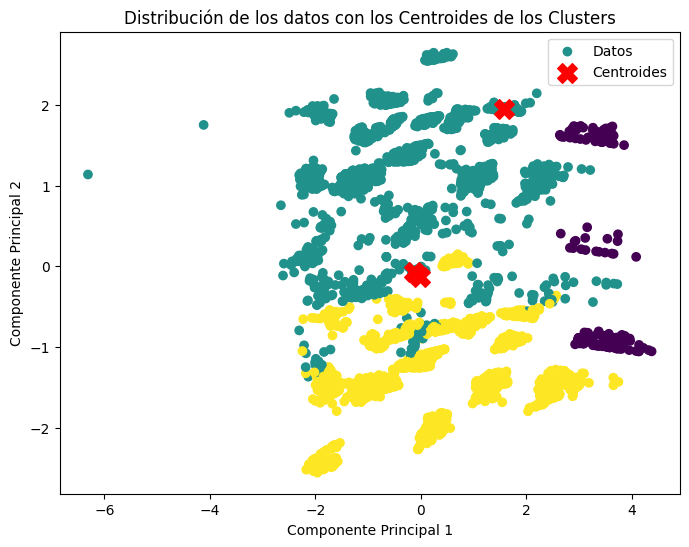

In [ ]:
# Crear un DataFrame para los centroides con los nombres de las variables
centroides_df = pd.DataFrame(centroides, columns=df_seleccionado.columns[:-1])  # Excluyendo la columna de cluster

# Visualización de los centroides sobre el gráfico de dispersión
# Usamos PCA para reducir las dimensiones a 2D para la visualización
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_normalizado)

# Visualización de los datos con los centroides
plt.figure(figsize=(8, 6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=df_seleccionado['Cluster_KMeans'], cmap='viridis', marker='o', label='Datos')
plt.scatter(centroides_df.iloc[:, 0], centroides_df.iloc[:, 1], c='red', marker='X', s=200, label='Centroides')
plt.title('Distribución de los datos con los Centroides de los Clusters')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.show()

In [ ]:
# Métricas de evaluación

# 1. Inercia (WCSS final)
inertia = kmeans.inertia_
# 2. Coeficiente de Silueta
silhouette_avg = silhouette_score(df_normalizado, df_seleccionado['Cluster_KMeans'])
# 3. Calinski-Harabasz Score
calinski_harabasz = calinski_harabasz_score(df_normalizado, df_seleccionado['Cluster_KMeans'])

In [ ]:
# Mostrar resultados
print(f"Inercia (WCSS final): {inertia}")
print(f"Coeficiente de Silueta: {silhouette_avg}")
print(f"Calinski-Harabasz Score: {calinski_harabasz}")

Inercia (WCSS final): 77471.63988900791
Coeficiente de Silueta: 0.11397701321290757
Calinski-Harabasz Score: 208.46132446302218


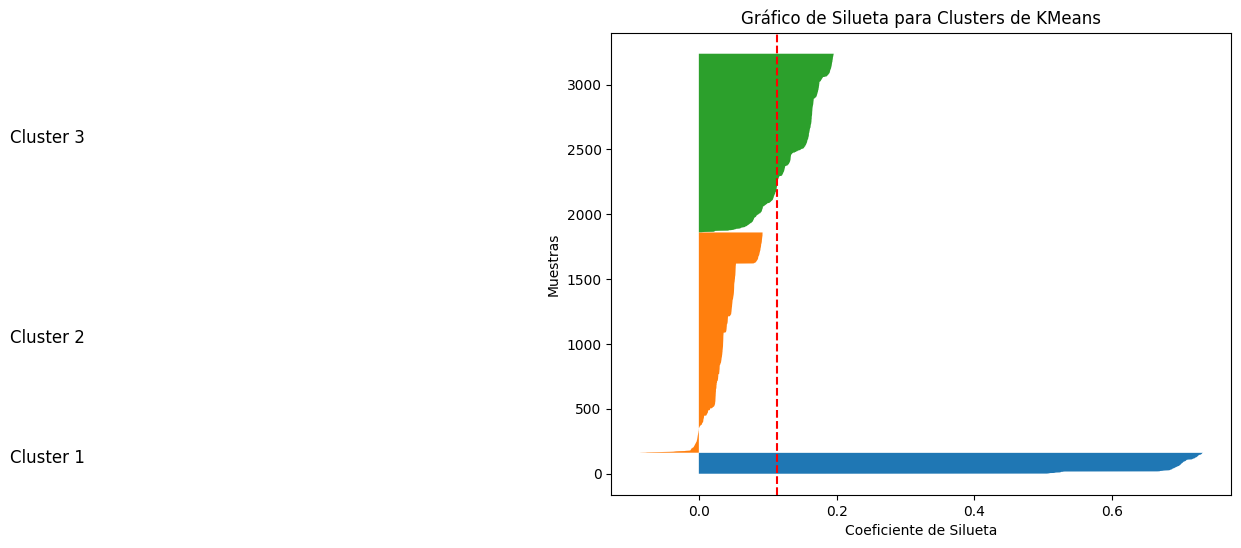

In [ ]:
# Visualización del gráfico de Silhouette
sample_silhouette_values = silhouette_samples(df_normalizado, df_seleccionado['Cluster_KMeans'])

plt.figure(figsize=(8, 6))
y_lower, y_upper = 0, 0
for i in range(3):  # Hay 3 clusters
    # Obtiene las muestras para cada cluster
    cluster_silhouette_values = sample_silhouette_values[df_seleccionado['Cluster_KMeans'] == i]
    cluster_silhouette_values.sort()
    y_upper += len(cluster_silhouette_values)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_values)
    plt.text(-1, (y_lower + y_upper) / 2, f'Cluster {i + 1}', fontsize=12)
    y_lower += len(cluster_silhouette_values)

plt.title('Gráfico de Silueta para Clusters de KMeans')
plt.xlabel('Coeficiente de Silueta')
plt.ylabel('Muestras')
plt.axvline(x=silhouette_avg, color="red", linestyle="--")
plt.show()

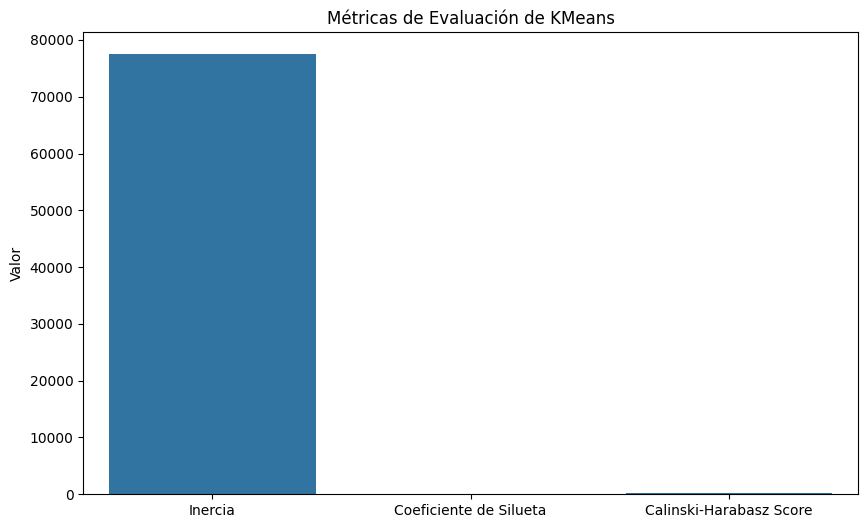

In [ ]:
# Histograma de las métricas de evaluación
metrics = [inertia, silhouette_avg, calinski_harabasz]
metrics_names = ['Inercia', 'Coeficiente de Silueta', 'Calinski-Harabasz Score']

plt.figure(figsize=(10, 6))
sns.barplot(x=metrics_names, y=metrics)
plt.title('Métricas de Evaluación de KMeans')
plt.ylabel('Valor')
plt.show()

In [ ]:
# Análisis de las zonas por cluster
# Contar las localidades dentro de cada cluster
zonas_por_cluster = df_seleccionado.groupby('Cluster_KMeans').agg(lambda x: x.mode()[0]).reset_index()

<ipython-input-22-c9650de000e0>:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color=plt.cm.get_cmap('tab20', len(zonas_por_cluster_dummies.columns))(range(len(zonas_por_cluster_dummies.columns))))


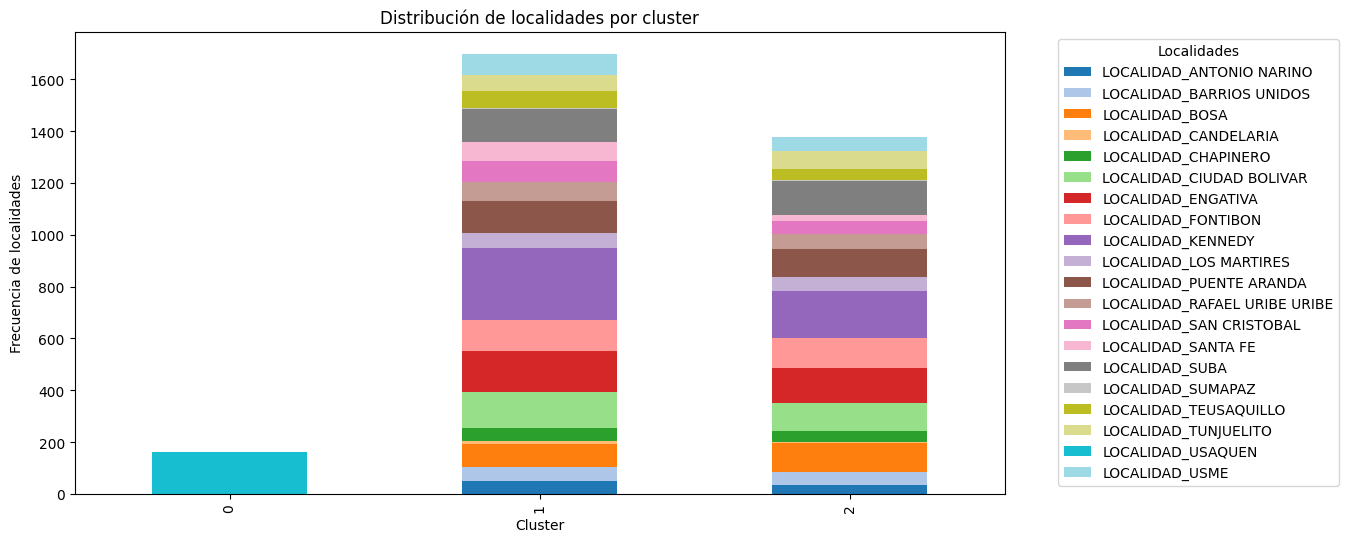

In [ ]:
# Visualizar las zonas en cada cluster (ya que las localidades se generaron con get_dummies)
zonas_por_cluster_dummies = df_seleccionado.groupby('Cluster_KMeans').sum().reset_index()
zonas_por_cluster_dummies = zonas_por_cluster_dummies.loc[:, zonas_por_cluster_dummies.columns.str.startswith('LOCALIDAD')]


# Graficar las zonas en cada cluster con colores diferentes por localidad
zonas_por_cluster_dummies.plot(kind='bar', figsize=(12, 6), stacked=True,
                               color=plt.cm.get_cmap('tab20', len(zonas_por_cluster_dummies.columns))(range(len(zonas_por_cluster_dummies.columns))))

# Configurar el título y etiquetas
plt.title('Distribución de localidades por cluster')
plt.xlabel('Cluster')
plt.ylabel('Frecuencia de localidades')

# Añadir leyenda
plt.legend(title='Localidades', bbox_to_anchor=(1.05, 1), loc='upper left')

# Mostrar gráfico
plt.show()

<ipython-input-23-287cd772c1f6>:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color=plt.cm.get_cmap('tab20', len(zonas_por_cluster_dummies.columns))(range(len(zonas_por_cluster_dummies.columns))))


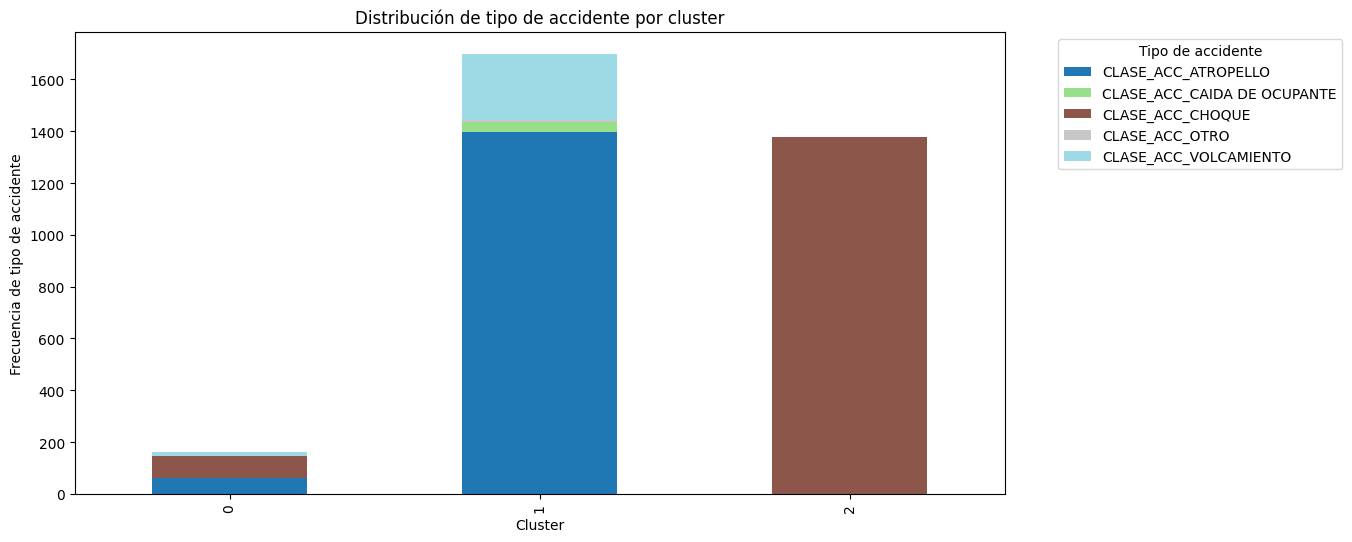

In [ ]:
# Visualizar las zonas en cada cluster (ya que las localidades se generaron con get_dummies)
zonas_por_cluster_dummies = df_seleccionado.groupby('Cluster_KMeans').sum().reset_index()
zonas_por_cluster_dummies = zonas_por_cluster_dummies.loc[:, zonas_por_cluster_dummies.columns.str.startswith('CLASE_ACC')]


# Graficar las zonas en cada cluster con colores diferentes por localidad
zonas_por_cluster_dummies.plot(kind='bar', figsize=(12, 6), stacked=True,
                               color=plt.cm.get_cmap('tab20', len(zonas_por_cluster_dummies.columns))(range(len(zonas_por_cluster_dummies.columns))))

# Configurar el título y etiquetas
plt.title('Distribución de tipo de accidente por cluster')
plt.xlabel('Cluster')
plt.ylabel('Frecuencia de tipo de accidente')

# Añadir leyenda
plt.legend(title='Tipo de accidente', bbox_to_anchor=(1.05, 1), loc='upper left')

# Mostrar gráfico
plt.show()


Zonas para el Cluster 0:


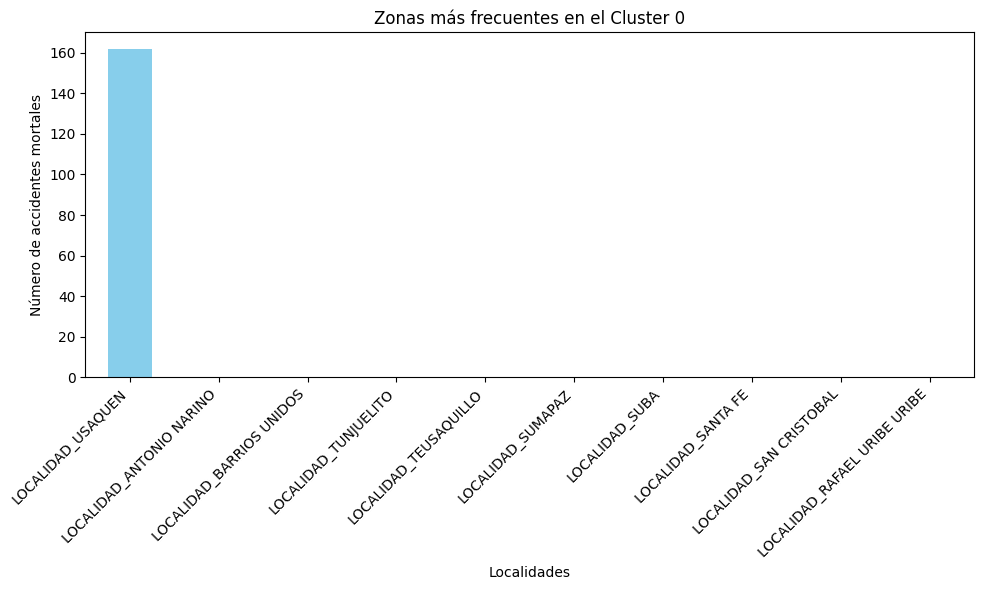


Zonas para el Cluster 1:


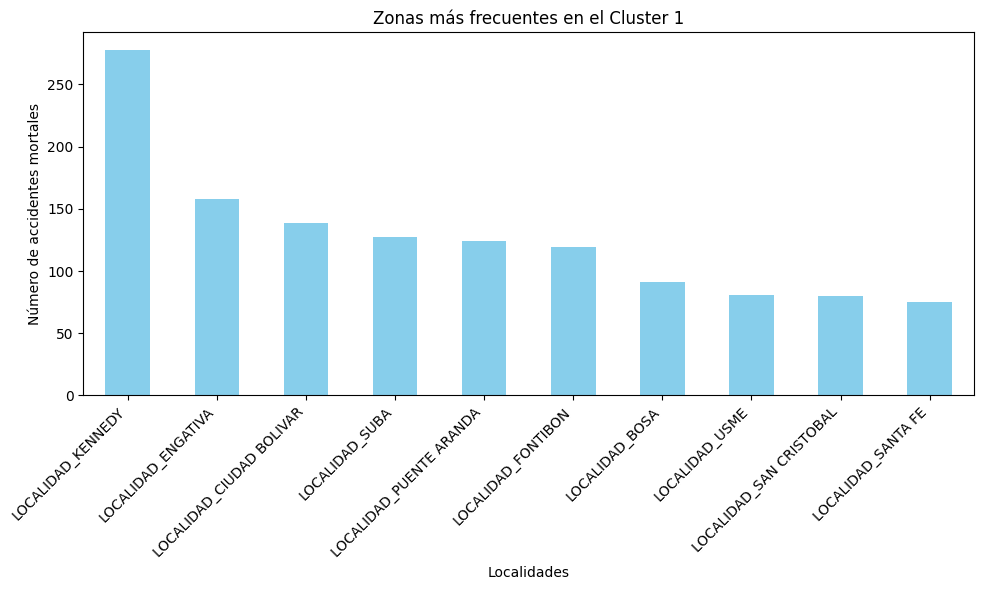


Zonas para el Cluster 2:


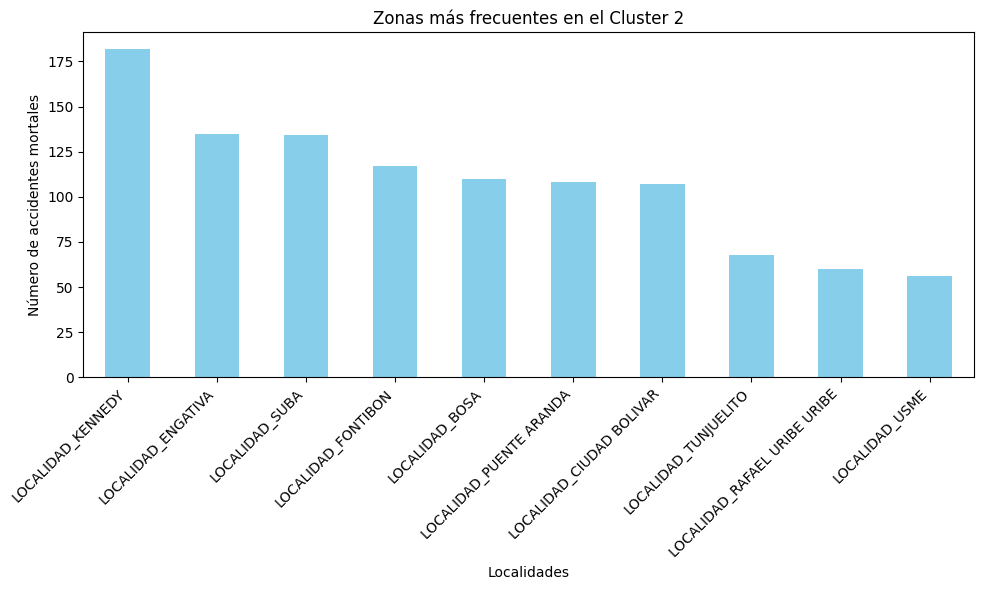

In [ ]:
import matplotlib.pyplot as plt

# Identificación de las zonas geográficas por cada cluster y graficar
for cluster_id in range(3):
    print(f"\nZonas para el Cluster {cluster_id}:")
    # Filtramos las filas correspondientes al cluster y luego encontramos las zonas
    cluster_data = df_seleccionado[df_seleccionado['Cluster_KMeans'] == cluster_id]

    # Sumamos las columnas relacionadas con LOCALIDAD, que ahora son variables dummy
    localities_columns = [col for col in cluster_data.columns if 'LOCALIDAD_' in col]
    locality_counts = cluster_data[localities_columns].sum().sort_values(ascending=False)

    # Graficar las zonas más representativas para este cluster
    plt.figure(figsize=(10, 6))
    locality_counts.head(10).plot(kind='bar', color='skyblue')  # Tomamos las 10 zonas más frecuentes
    plt.title(f'Zonas más frecuentes en el Cluster {cluster_id}')
    plt.xlabel('Localidades')
    plt.ylabel('Número de accidentes mortales')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


La columna 'Cluster_KMeans' no existe. Realizando la asignación de clusters...


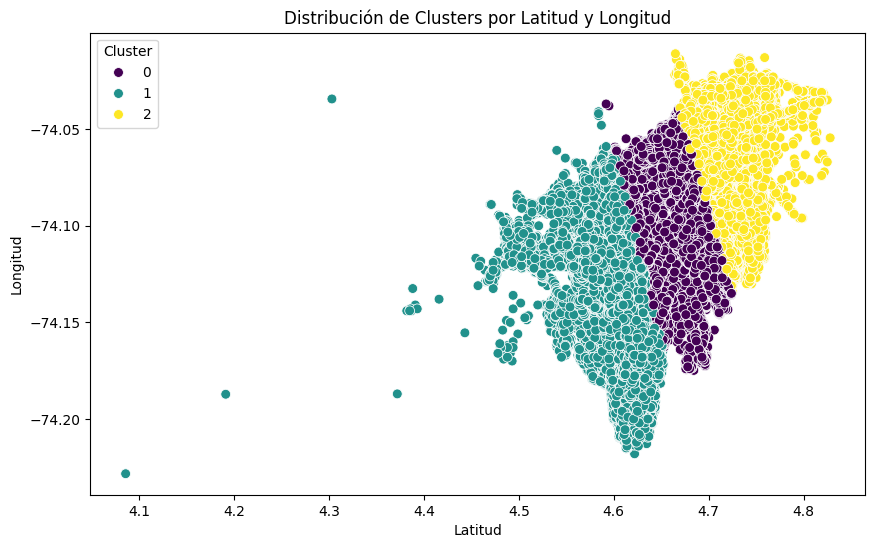

In [ ]:
# Verifica si ya tienes asignados los clusters en 'Cluster_KMeans'
if 'Cluster_KMeans' not in df.columns:
    # Si no existe la columna 'Cluster_KMeans', la creamos usando K-Means
    print("La columna 'Cluster_KMeans' no existe. Realizando la asignación de clusters...")
    kmeans = KMeans(n_clusters=3, random_state=42)
    df['Cluster_KMeans'] = kmeans.fit_predict(df[['LATITUD', 'LONGITUD']])

# Graficamos la dispersión de latitud vs longitud, diferenciando por el cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='LATITUD', y='LONGITUD', hue='Cluster_KMeans', palette='viridis', s=50)

# Títulos y etiquetas
plt.title('Distribución de Clusters por Latitud y Longitud')
plt.xlabel('Latitud')
plt.ylabel('Longitud')

# Leyenda
plt.legend(title='Cluster', loc='best')

# Mostrar el gráfico
plt.show()

# Agrupamiento con Clustering Jerárquico

In [ ]:
# Realizar el linkage
Z = linkage(df_normalizado, method='ward',metric='euclidean')

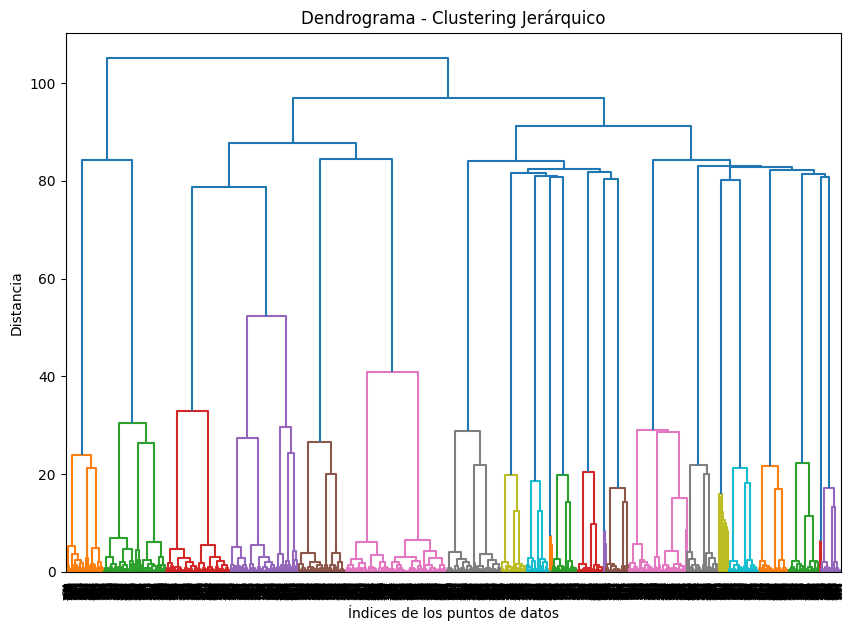

In [ ]:
# Graficar el dendrograma
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Dendrograma - Clustering Jerárquico')
plt.xlabel('Índices de los puntos de datos')
plt.ylabel('Distancia')
plt.show()

In [ ]:
# Obtener las distancias de enlace de las últimas fusiones (generalmente son las más relevantes)
last = Z[-10:, 2]  # Distancias de las últimas fusiones
last_rev = last[::-1]  # Invertir para verlo en orden ascendente
print("Distancias de las últimas fusiones (generalmente son las más relevantes):")
print(last_rev)

Distancias de las últimas fusiones (generalmente son las más relevantes):
[105.05966439  96.90341088  91.1862853   87.7295626   84.54544399
  84.31727373  84.28902011  83.96697096  83.09859239  82.91689744]


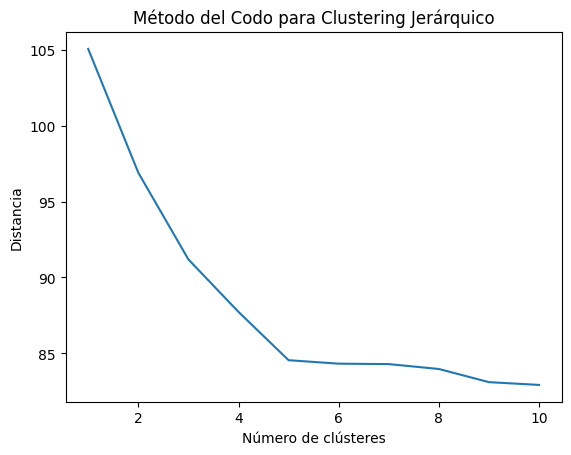

In [ ]:
# Crear un índice de los clústeres (por ejemplo, 1, 2, 3,...)
idx = np.arange(1, len(last) + 1)

# Graficar la distancia de enlace frente al número de clústeres
plt.plot(idx, last_rev)
plt.xlabel('Número de clústeres')
plt.ylabel('Distancia')
plt.title('Método del Codo para Clustering Jerárquico')
plt.show()

In [ ]:
max_d=85
clusters_d = fcluster(Z, max_d, criterion="distance")
clusters_d

# Añadir los clusters jerárquicos al DataFrame como una nueva columna
df_seleccionado['Cluster_Jerarquico'] = clusters_d

In [ ]:
# Ver cuántos clústeres se han formado
num_clusters = len(np.unique(clusters_d))
print(f"Se han formado {num_clusters} clústeres con el umbral de distancia {max_d}.")

Se han formado 5 clústeres con el umbral de distancia 85.


Text(0.5, 1.0, 'Clústeres por Distancia (max_d=85)')

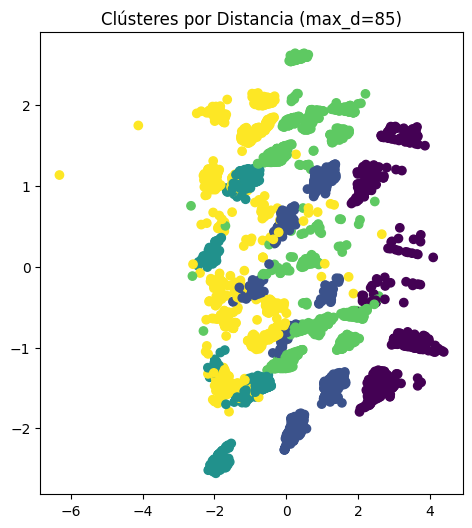

In [ ]:
# Visualización de los clústeres obtenidos por corte por distancia (max_d=2)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=clusters_d, cmap='viridis')
plt.title('Clústeres por Distancia (max_d=85)')

In [ ]:
cluster_labels = np.unique(clusters_d)  # Etiquetas de los clusters
n_clusters = cluster_labels.shape[0]   # Número de clusters
silhouette_vals = silhouette_samples(df_normalizado, clusters_d, metric='euclidean')  # Valores del índice de Silueta

# Para los gráficos de Silueta
y_ax_lower, y_ax_upper = 0, 0
yticks = []

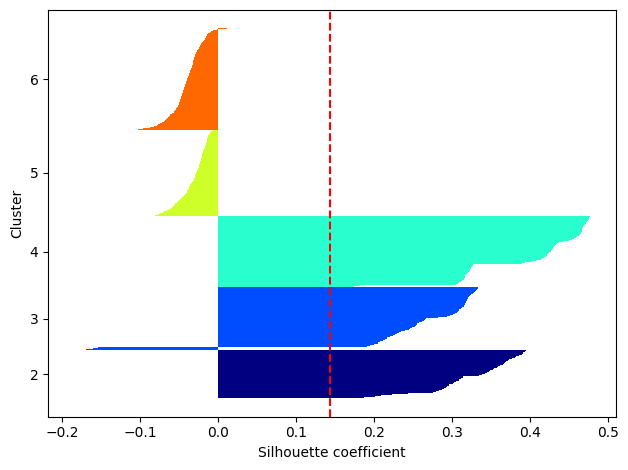

In [ ]:
# Se genera el gráfico de Silueta para cada clúster
for i, c in enumerate(cluster_labels):
    c_silhouette_vals = silhouette_vals[clusters_d == c]  # Valores de Silueta del clúster
    c_silhouette_vals.sort()  # Ordenar los valores de Silueta dentro del clúster
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / n_clusters)  # Color asignado a cada clúster
    plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0,
             edgecolor='none', color=color)  # Crear la barra para cada clúster

    yticks.append((y_ax_lower + y_ax_upper) / 2.)  # Marca de posición para cada clúster
    y_ax_lower += len(c_silhouette_vals)  # Actualizar la posición para el siguiente clúster

# Promedio de la silueta para todos los puntos
silhouette_avg = np.mean(silhouette_vals)
plt.axvline(silhouette_avg, color="red", linestyle="--")  # Línea roja indicando el promedio

# Etiquetas y configuración del gráfico
plt.yticks(yticks, cluster_labels + 1)  # Agregar etiquetas en el eje y
plt.ylabel('Cluster')
plt.xlabel('Silhouette coefficient')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

<ipython-input-35-6b15235178d4>:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color=plt.cm.get_cmap('tab20', len(zonas_por_cluster_dummies.columns))(range(len(zonas_por_cluster_dummies.columns))))


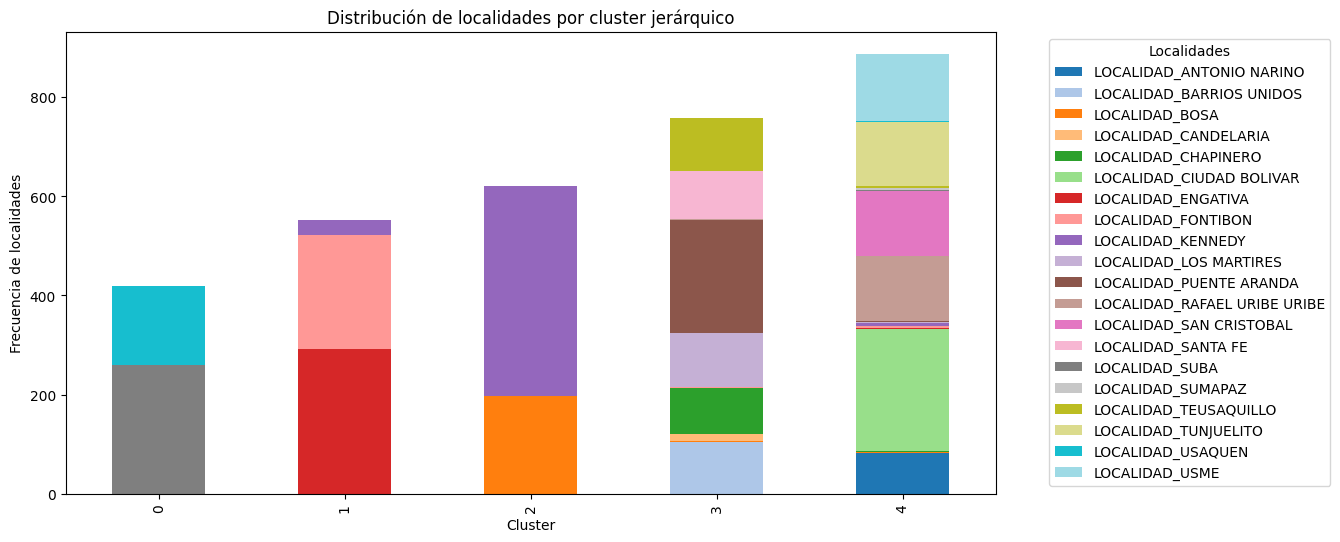

In [ ]:
# Agrupar las zonas por cada cluster obtenido del clustering jerárquico
zonas_por_cluster_dummies = df_seleccionado.groupby('Cluster_Jerarquico').sum().reset_index()
zonas_por_cluster_dummies = zonas_por_cluster_dummies.loc[:, zonas_por_cluster_dummies.columns.str.startswith('LOCALIDAD')]

# Graficar las zonas en cada cluster con colores diferentes por localidad
zonas_por_cluster_dummies.plot(kind='bar', figsize=(12, 6), stacked=True,
                               color=plt.cm.get_cmap('tab20', len(zonas_por_cluster_dummies.columns))(range(len(zonas_por_cluster_dummies.columns))))

# Configurar el título y etiquetas
plt.title('Distribución de localidades por cluster jerárquico')
plt.xlabel('Cluster')
plt.ylabel('Frecuencia de localidades')

# Añadir leyenda
plt.legend(title='Localidades', bbox_to_anchor=(1.05, 1), loc='upper left')

# Mostrar gráfico
plt.show()

<ipython-input-36-d5efe2b7f3f0>:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color=plt.cm.get_cmap('tab20', len(zonas_por_cluster_dummies.columns))(range(len(zonas_por_cluster_dummies.columns))))


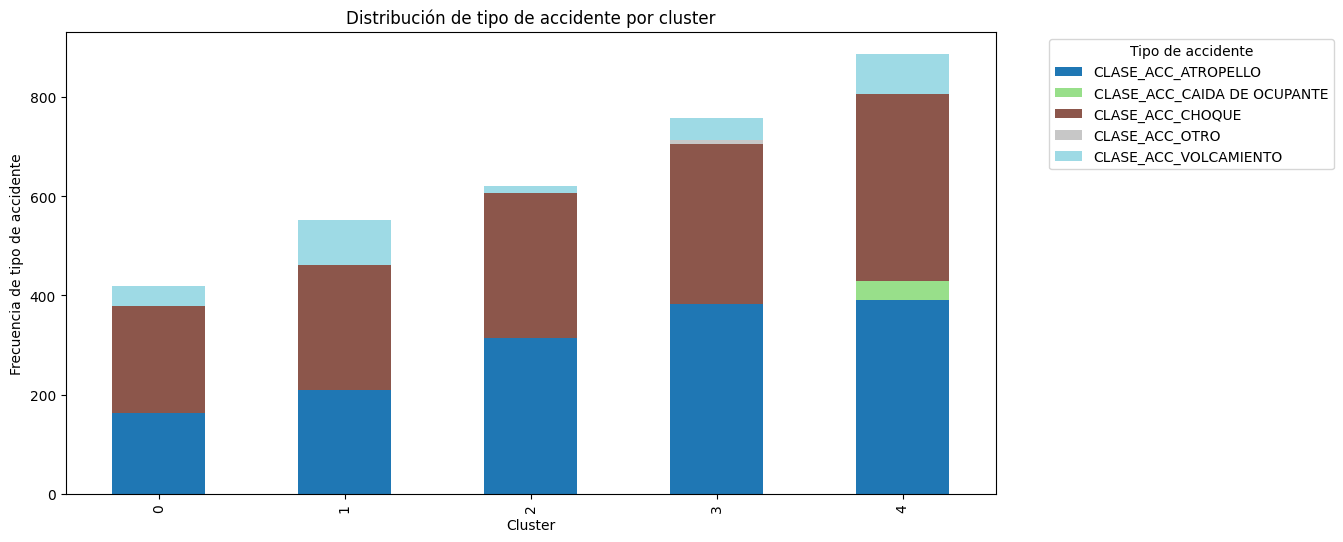

In [ ]:
# Visualizar las zonas en cada cluster (ya que las localidades se generaron con get_dummies)
zonas_por_cluster_dummies = df_seleccionado.groupby('Cluster_Jerarquico').sum().reset_index()
zonas_por_cluster_dummies = zonas_por_cluster_dummies.loc[:, zonas_por_cluster_dummies.columns.str.startswith('CLASE_ACC')]


# Graficar las zonas en cada cluster con colores diferentes por localidad
zonas_por_cluster_dummies.plot(kind='bar', figsize=(12, 6), stacked=True,
                               color=plt.cm.get_cmap('tab20', len(zonas_por_cluster_dummies.columns))(range(len(zonas_por_cluster_dummies.columns))))

# Configurar el título y etiquetas
plt.title('Distribución de tipo de accidente por cluster')
plt.xlabel('Cluster')
plt.ylabel('Frecuencia de tipo de accidente')

# Añadir leyenda
plt.legend(title='Tipo de accidente', bbox_to_anchor=(1.05, 1), loc='upper left')

# Mostrar gráfico
plt.show()

# Nuevo modelo


In [2]:
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import umap
from sklearn.neighbors import NearestNeighbors

In [4]:
def compare_pca_thresholds(df_normalizado, thresholds=[0.85, 0.90, 0.95]):
    """
    Compara diferentes umbrales de varianza explicada para PCA
    """
    pca = PCA()
    pca.fit(df_normalizado)
    cumsum = np.cumsum(pca.explained_variance_ratio_)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(cumsum) + 1), cumsum, 'bo-')
    for threshold in thresholds:
        n_components = np.argmax(cumsum >= threshold) + 1
        plt.axhline(y=threshold, color='r', linestyle='--',
                   label=f'Umbral {threshold} (n={n_components})')
    plt.xlabel('Número de componentes')
    plt.ylabel('Varianza explicada acumulada')
    plt.title('Comparación de umbrales de varianza explicada')
    plt.legend()
    plt.grid(True)
    plt.show()

    return {threshold: np.argmax(cumsum >= threshold) + 1 for threshold in thresholds}

def optimize_dbscan_params(X, min_samples_range=[3, 5, 10, 15, 20]):
    """
    Optimiza los parámetros de DBSCAN probando diferentes valores de min_samples
    """
    results = []

    # Calcular epsilon óptimo base
    neighbors = NearestNeighbors(n_neighbors=2)
    neighbors_fit = neighbors.fit(X)
    distances, _ = neighbors_fit.kneighbors(X)
    distances = np.sort(distances[:, 1])
    knee = np.diff(distances, 2)
    epsilon = distances[np.argmax(knee) + 1]

    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
        clusters = dbscan.fit_predict(X)

        if len(np.unique(clusters)) > 1:  # Si hay más de un cluster
            mask = clusters != -1
            if np.sum(mask) > 1:  # Si hay más de un punto no considerado ruido
                score = silhouette_score(X[mask], clusters[mask])
            else:
                score = 0
        else:
            score = 0

        n_clusters = len(np.unique(clusters[clusters != -1]))
        n_noise = np.sum(clusters == -1)

        results.append({
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette_score': score
        })

    return pd.DataFrame(results)

def visualize_multiple_projections(X, clusters):
    """
    Crea visualizaciones usando diferentes técnicas de reducción de dimensionalidad
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
    axes[0].set_title('PCA')

    # t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(X)
    axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap='viridis')
    axes[1].set_title('t-SNE')

    # UMAP
    reducer = umap.UMAP(random_state=42)
    X_umap = reducer.fit_transform(X)
    axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=clusters, cmap='viridis')
    axes[2].set_title('UMAP')

    plt.tight_layout()
    plt.show()

def analyze_cluster_characteristics(df_original, clusters):
    """
    Analiza las características predominantes en cada cluster
    """
    df_original = df_original.copy()
    df_original['Cluster'] = clusters

    cluster_summary = []

    for cluster in np.unique(clusters):
        if cluster != -1:
            cluster_data = df_original[df_original['Cluster'] == cluster]

            # Características numéricas
            numeric_summary = {
                'Cluster': cluster,
                'Tamaño': len(cluster_data),
                'Latitud_promedio': cluster_data['LATITUD'].mean(),
                'Longitud_promedio': cluster_data['LONGITUD'].mean()
            }

            # Encontrar las características más comunes
            categorical_cols = df_original.select_dtypes(include=['object']).columns
            for col in categorical_cols:
                if col != 'Cluster':
                    top_value = cluster_data[col].mode().iloc[0]
                    numeric_summary[f'{col}_más_común'] = top_value

            cluster_summary.append(numeric_summary)

    return pd.DataFrame(cluster_summary)

1. Comparando diferentes umbrales de PCA...


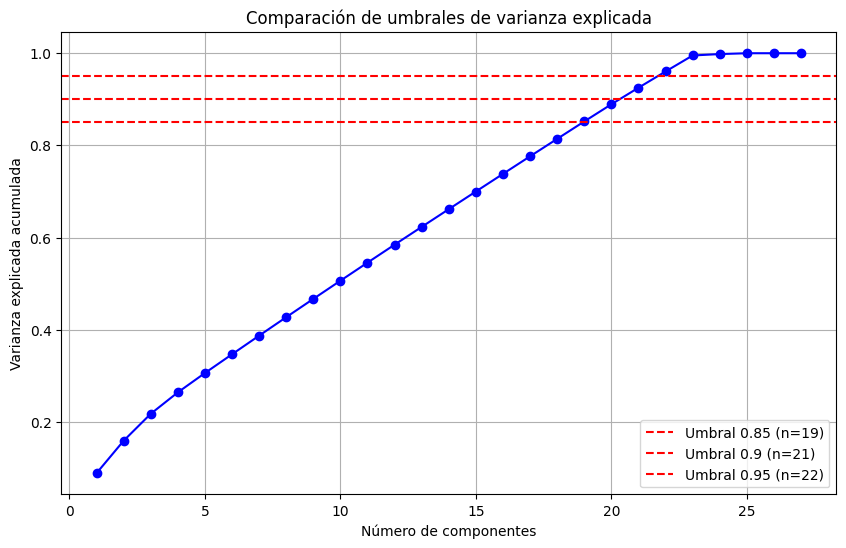


Número de componentes necesarios para cada umbral:
Umbral 85.0%: 19 componentes
Umbral 90.0%: 21 componentes
Umbral 95.0%: 22 componentes


In [17]:
# Paso 1: Comparación de umbrales PCA
print("1. Comparando diferentes umbrales de PCA...")
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def analyze_pca_thresholds():
    pca_components = compare_pca_thresholds(df_normalizado)
    print("\nNúmero de componentes necesarios para cada umbral:")
    for threshold, n_components in pca_components.items():
        print(f"Umbral {threshold*100}%: {n_components} componentes")
    return pca_components

# Ejecutar análisis PCA
pca_results = analyze_pca_thresholds()

In [18]:
# Paso 2: Aplicar PCA con umbral seleccionado
print("\n2. Aplicando PCA con umbral del 90%...")
def apply_pca(n_components):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(df_normalizado)
    print(f"Dimensiones después de PCA: {X_pca.shape}")
    return X_pca, pca

X_pca, pca_model = apply_pca(pca_results[0.90])


2. Aplicando PCA con umbral del 90%...
Dimensiones después de PCA: (3239, 21)


In [19]:
# Paso 3: Optimización de parámetros DBSCAN
print("\n3. Optimizando parámetros de DBSCAN...")
def optimize_dbscan():
    dbscan_results = optimize_dbscan_params(X_pca)
    print("\nResultados de la optimización de DBSCAN:")
    print(dbscan_results)

    # Encontrar mejores parámetros
    best_params = dbscan_results.loc[dbscan_results['silhouette_score'].idxmax()]
    print("\nMejores parámetros encontrados:")
    print(f"min_samples: {best_params['min_samples']}")
    print(f"Silhouette Score: {best_params['silhouette_score']:.4f}")
    return dbscan_results

dbscan_optimization = optimize_dbscan()


3. Optimizando parámetros de DBSCAN...

Resultados de la optimización de DBSCAN:
   min_samples  n_clusters  n_noise  silhouette_score
0            3          62       28          0.885929
1            5          56       48          0.885677
2           10          47      105          0.884705
3           15          44      141          0.884215
4           20          41      189          0.884296

Mejores parámetros encontrados:
min_samples: 3.0
Silhouette Score: 0.8859


In [20]:
# Paso 4: Calcular epsilon óptimo
print("\n4. Calculando epsilon óptimo...")
def calculate_optimal_epsilon(X_pca, dbscan_results):
    best_min_samples = dbscan_results.loc[dbscan_results['silhouette_score'].idxmax(), 'min_samples']

    neighbors = NearestNeighbors(n_neighbors=2)
    neighbors_fit = neighbors.fit(X_pca)
    distances, _ = neighbors_fit.kneighbors(X_pca)

    distances_sorted = np.sort(distances[:, 1])
    knee_point = np.argmax(np.diff(distances_sorted, 2)) + 1
    epsilon = distances_sorted[knee_point]

    print(f"Epsilon óptimo calculado: {epsilon:.4f}")
    return epsilon, int(best_min_samples)

epsilon, best_min_samples = calculate_optimal_epsilon(X_pca, dbscan_optimization)


4. Calculando epsilon óptimo...
Epsilon óptimo calculado: 2.3953


In [21]:
# Paso 5: Aplicar DBSCAN con parámetros optimizados
print("\n5. Aplicando DBSCAN con parámetros optimizados...")
def apply_optimized_dbscan(X_pca, epsilon, min_samples):
    dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
    clusters = dbscan.fit_predict(X_pca)

    n_clusters = len(np.unique(clusters[clusters != -1]))
    n_noise = np.sum(clusters == -1)

    print(f"Número de clusters encontrados: {n_clusters}")
    print(f"Número de puntos de ruido: {n_noise}")
    return clusters

clusters = apply_optimized_dbscan(X_pca, epsilon, best_min_samples)


5. Aplicando DBSCAN con parámetros optimizados...
Número de clusters encontrados: 62
Número de puntos de ruido: 28



6. Visualizando resultados...
Generando visualizaciones múltiples...


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited at iteration 2000 with accuracies 
[1.48650138e-14 9.06929046e-08 3.49866585e-07 3.48591194e-06]
not reaching the requested tolerance 6.854534149169922e-07.
Use iteration 1241 instead with accuracy 
5.02335400878489e-07.

  _, diffusion_map = lobpcg(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited postprocessing with accuracies 
[3.62172255e-15 6.54416217e-08 3.94260459e-07 1.54963949e-06]
not reaching the requested tolerance 6.854534149169922e-07.
  _, diffusion_map = lobpcg(


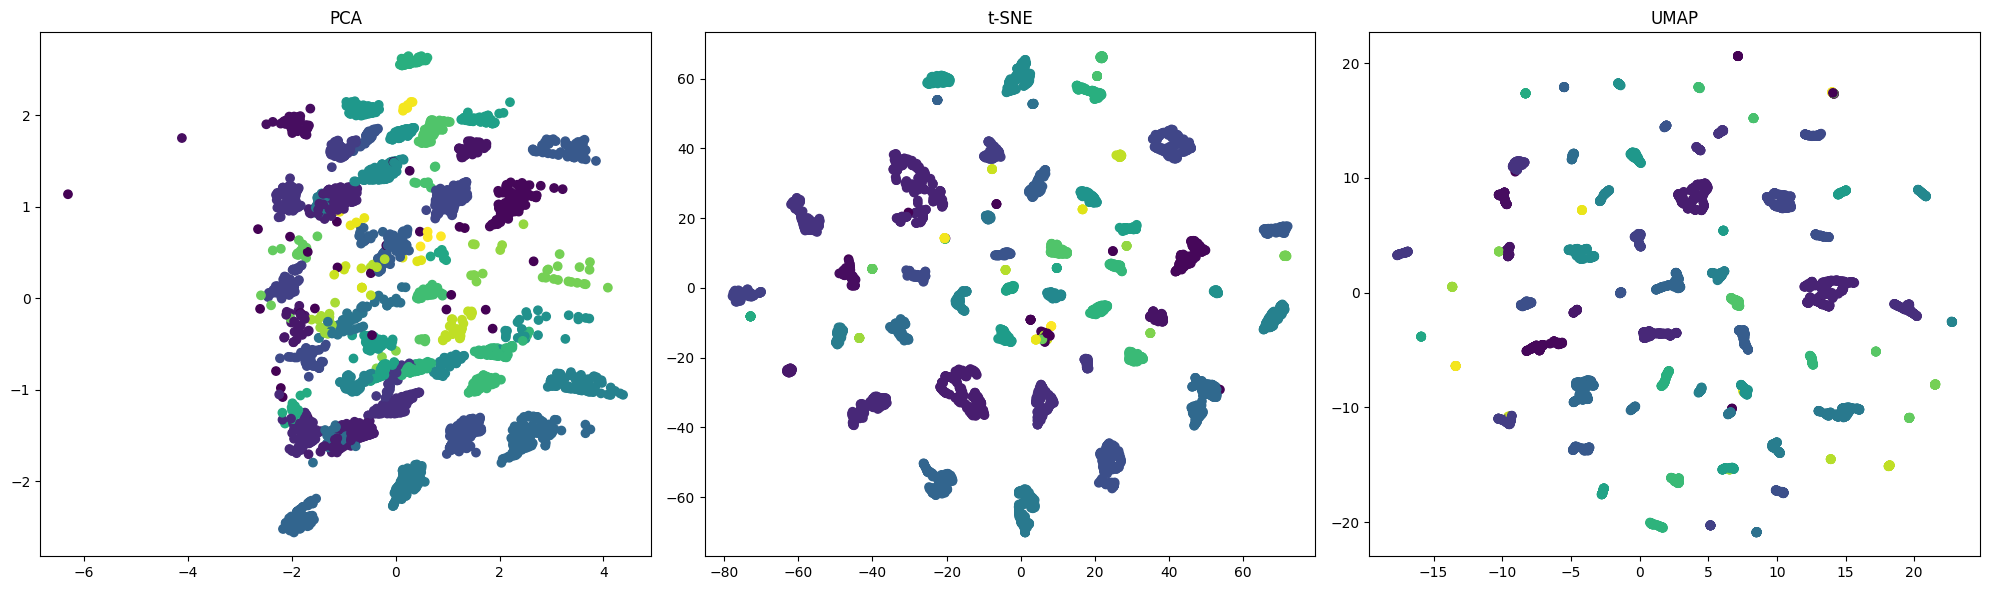

In [22]:
# Paso 6: Visualizar resultados
print("\n6. Visualizando resultados...")
def visualize_results():
    print("Generando visualizaciones múltiples...")
    visualize_multiple_projections(X_pca, clusters)
    plt.show()

visualize_results()

In [23]:
# Paso 7: Analizar características de los clusters
print("\n7. Analizando características de los clusters...")
def analyze_clusters():
    cluster_characteristics = analyze_cluster_characteristics(df_seleccionado, clusters)
    print("\nCaracterísticas de los clusters:")
    print(cluster_characteristics)
    return cluster_characteristics

cluster_analysis = analyze_clusters()


7. Analizando características de los clusters...

Características de los clusters:
    Cluster  Tamaño  Latitud_promedio  Longitud_promedio
0         0     101          4.732953         -74.085288
1         1      64          4.508749         -74.115017
2         2      49          4.668264         -74.072800
3         3      31          4.565423         -74.150034
4         4     182          4.627726         -74.151091
..      ...     ...               ...                ...
57       57       3          4.607309         -74.126786
58       58       3          4.612310         -74.086019
59       59       5          4.557898         -74.093805
60       60       8          4.594437         -74.077280
61       61       4          4.636987         -74.080857

[62 rows x 4 columns]


In [24]:
# Paso 8: Calcular métricas finales
print("\n8. Calculando métricas finales...")
def calculate_final_metrics(X_pca, clusters):
    n_clusters = len(np.unique(clusters[clusters != -1]))
    n_noise = np.sum(clusters == -1)

    if n_clusters > 1:
        mask = clusters != -1
        silhouette_avg = silhouette_score(X_pca[mask], clusters[mask])
    else:
        silhouette_avg = 0

    print("\nMétricas finales:")
    print(f"Número de clusters: {n_clusters}")
    print(f"Puntos de ruido: {n_noise}")
    print(f"Silhouette score: {silhouette_avg:.4f}")

    return {
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'silhouette_score': silhouette_avg
    }

final_metrics = calculate_final_metrics(X_pca, clusters)


8. Calculando métricas finales...

Métricas finales:
Número de clusters: 62
Puntos de ruido: 28
Silhouette score: 0.8859
